# PIPELINE PER LA CLASSIFICAZIONE DELLE PRIORITA' DEI TICKET

# 1. Importazione delle librerie

In [56]:
import pandas as pd # Serve per leggere e gestire i CSV
import re

from sklearn.feature_extraction.text import TfidfVectorizer # Trasforma il testo in numeri
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
) # Serve per valutare il modello
import matplotlib.pyplot as plt # Serve per la matrice di confusione

# 2. Caricamento dei Dataset e conversione in DataFrame Pandas

In [57]:
# Verifica del caricamento del dataset training
df_train = pd.read_csv('dataset_ticket_train.csv')

# Verifica del caricamento del dataset validation
df_valid = pd.read_csv('dataset_ticket_valid.csv')

# Verifica del caricamento del dataset test
df_test = pd.read_csv('dataset_ticket_test.csv')

# Verifica del caricamento dei dataset
print('Train:', df_train.shape, df_train['priority'].value_counts())
print('Valid:', df_valid.shape, df_valid['priority'].value_counts())
print('Test:', df_test.shape, df_test['priority'].value_counts())

Train: (398, 5) priority
bassa    154
media    144
alta     100
Name: count, dtype: int64
Valid: (50, 5) priority
bassa    21
media    20
alta      9
Name: count, dtype: int64
Test: (50, 5) priority
bassa    20
media    16
alta     14
Name: count, dtype: int64


# 3. Controllo colonne e dati CSV

In [58]:
print("Colonne presenti correttamente:")
print(df_train.columns.tolist())

print("\nPrime righe del dataset di training:")
display(df_train.head())


Colonne presenti correttamente:
['id', 'title', 'body', 'category', 'priority']

Prime righe del dataset di training:


,id,title,body,category,priority
0,36tyn39n,Richiesta fattura per mese corrente,Non riesco a reperire il documento fiscale rel...,Amministrazione,media
1,50nwbvku,Disponibilità articolo portachiavi promozionali,È prevista una nuova disponibilità per 200 sho...,Commerciale,bassa
2,90x1eun4,Richiesta di supporto per configuratore gadget,Sarei interessato a conoscere maggiormente alc...,Tecnico,bassa
3,c54cjlkp,Richiesta rimborso per servizio premium,Il servizio la posizione cliente CLI-789 non c...,Amministrazione,media
4,eoti1a1e,Richiesta fattura per mese corrente,Nei nostri archivi non compare il documento la...,Amministrazione,media


# 4. Preparazione dei dati

In [60]:
# Dataset train
x_train = df_train["title"] + " " + df_train["body"]
y_train_priorita = df_train["priority"]

# Dataset validation
x_valid = df_valid["title"] + " " + df_valid["body"]
y_valid_priorita = df_valid["priority"]

# Dataset test
x_test = df_test["title"] + " " + df_test["body"]
y_test_priorita = df_test["priority"]

# 5. Preprocessing del testo

In [61]:
# Pulizia di base del testo
def pulisci_testo(testo):
    testo = testo.lower()
    testo = re.sub(r"[^\w\s]", " ", testo)
    testo = re.sub(r"\s+", " ", testo)
    testo = testo.strip()
    return testo

x_train = x_train.apply(pulisci_testo)
x_valid = x_valid.apply(pulisci_testo)
x_test = x_test.apply(pulisci_testo)

print("Esempio di testo dopo il preprocessing")
print(x_train.iloc[0])

Esempio di testo dopo il preprocessing
richiesta fattura per mese corrente non riesco a reperire il documento fiscale relativo al servizio di supporto potreste inviarla


# 6. Creazione pipeline TF-IDF e Logistic Regression priorità

In [62]:
# Creazione della pipeline per la classificazione delle priorità
pipeline_priorita = Pipeline([

    # Trasformazione del testo in valori numerici tramite TF-IDF
    ("tfidf", TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    sublinear_tf=True
    )),

    # Creazione del modello di classificazione Logistic Regression
    ("logreg", LogisticRegression(
        max_iter=1000
    ))
])

# Verifica della corretta creazione della pipeline
print("Pipeline per la classificazione delle priorità creata correttamente.")

Pipeline per la classificazione delle priorità creata correttamente.


# 7. Addestramento del modello

In [63]:
# Ricerca dei migliori parametri per la priorità

parametri_priorita = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "logreg__C": [0.01, 0.1, 1, 10],
    "logreg__class_weight": [None, "balanced"]
}

grid_search_priorita = GridSearchCV(
    pipeline_priorita,
    parametri_priorita,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# Addestramento della Grid Search sul training set
grid_search_priorita.fit(x_train, y_train_priorita)

# Visualizzazione dei migliori parametri trovati
print("Migliori parametri per la priorità:")
print(grid_search_priorita.best_params_)
print("Miglior F1 macro ottenuto in cross-validation:",
      round(grid_search_priorita.best_score_, 4))

Migliori parametri per la priorità:
{'logreg__C': 10, 'logreg__class_weight': None, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Miglior F1 macro ottenuto in cross-validation: 0.9561


# 8. Valutazione validation e test set

In [64]:
# Previsione della priorità sul validation set
y_valid_pred_priorita = grid_search_priorita.predict(x_valid)
# Calcolo Accuracy del validation
accuracy_valid_priorita = accuracy_score(y_valid_priorita, y_valid_pred_priorita)
# Calcolo F1 macro del validation
f1_valid_priorita = f1_score(
    y_valid_priorita,
    y_valid_pred_priorita,
    average="macro"
)

print("Risultati VALIDATION - PRIORITÀ")
print("Accuracy:", round(accuracy_valid_priorita, 4))
print("F1 macro:", round(f1_valid_priorita, 4))

print("Classification report - VALIDATION")
print(classification_report(y_valid_priorita, y_valid_pred_priorita))


# Previsione della priorità sul test set
y_test_pred_priorita = grid_search_priorita.predict(x_test)
# Calcolo Accuracy del test
accuracy_test_priorita = accuracy_score(
    y_test_priorita,
    y_test_pred_priorita
)
# Calcolo F1 macro del test
f1_test_priorita = f1_score(
    y_test_priorita,
    y_test_pred_priorita,
    average="macro"
)

print("Risultati TEST - PRIORITÀ")
print("Accuracy:", round(accuracy_test_priorita, 4))
print("F1 macro:", round(f1_test_priorita, 4))

print("Classification report - TEST")
print(classification_report(y_test_priorita, y_test_pred_priorita))

Risultati VALIDATION - PRIORITÀ
Accuracy: 0.94
F1 macro: 0.9405
Classification report - VALIDATION
              precision    recall  f1-score   support

        alta       1.00      0.89      0.94         9
       bassa       1.00      0.90      0.95        21
       media       0.87      1.00      0.93        20

    accuracy                           0.94        50
   macro avg       0.96      0.93      0.94        50
weighted avg       0.95      0.94      0.94        50

Risultati TEST - PRIORITÀ
Accuracy: 0.98
F1 macro: 0.9776
Classification report - TEST
              precision    recall  f1-score   support

        alta       1.00      0.93      0.96        14
       bassa       1.00      1.00      1.00        20
       media       0.94      1.00      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [66]:
# Visualizzazione dei ticket classificati in modo errato

errori_priorita = df_test[
    y_test_priorita != y_test_pred_priorita
].copy()

errori_priorita["priorita_predetta"] = y_test_pred_priorita[
    y_test_priorita != y_test_pred_priorita
]

display(
    errori_priorita[
        ["title", "body", "priority", "priorita_predetta"]
    ]
)

,title,body,priority,priorita_predetta
0,Disguido con richiesta cliente borse e shopper,I dati associati a materiale promozionale per ...,alta,media


# 9. Creazione matrice di confusione

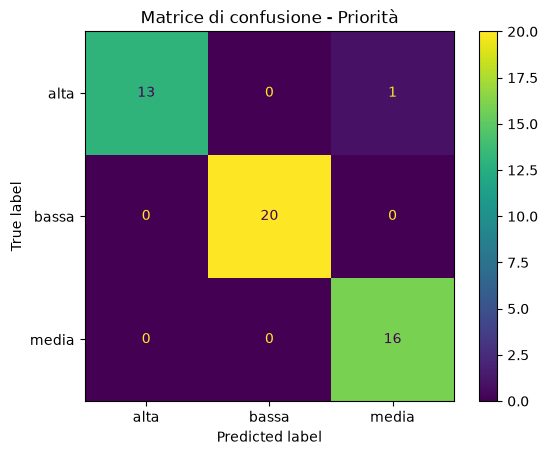

In [67]:
# Calcolo della matrice di confusione sul test set
cm_priorita = confusion_matrix(
    y_test_priorita,
    y_test_pred_priorita
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_priorita,
    display_labels=grid_search_priorita.classes_
)

# Visualizzazione della matrice
disp.plot()

plt.title("Matrice di confusione - Priorità")
plt.show()

# 10. Controllo overfitting

In [68]:
# Previsione della priorità sul training set
y_train_pred_priorita = grid_search_priorita.predict(x_train)

# Calcolo Accuracy del training
accuracy_train_priorita = accuracy_score(
    y_train_priorita,
    y_train_pred_priorita
)

# Calcolo F1 macro sul training
f1_train_priorita = f1_score(
    y_train_priorita,
    y_train_pred_priorita,
    average="macro"
)

print("Accuracy TRAIN:", round(accuracy_train_priorita, 4))
print("F1 macro TRAIN:", round(f1_train_priorita, 4))

print("\nAccuracy TEST:", round(accuracy_test_priorita, 4))
print("F1 macro TEST:", round(f1_test_priorita, 4))

print("\nDifferenza Accuracy train-test:",
      round(accuracy_train_priorita - accuracy_test_priorita, 4))

print("Differenza F1 train-test:",
      round(f1_train_priorita - f1_test_priorita, 4))

Accuracy TRAIN: 1.0
F1 macro TRAIN: 1.0

Accuracy TEST: 0.98
F1 macro TEST: 0.9776

Differenza Accuracy train-test: 0.02
Differenza F1 train-test: 0.0224


In [69]:
# Salvataggio del modello definitivo
import joblib

modello_priorita_definitivo = grid_search_priorita.best_estimator_

joblib.dump(
    modello_priorita_definitivo,
    "Logistic_Regression_definitiva_priorita.pkl"
)

print("Modello definitivo per la classificazione delle priorità salvato correttamente.")

Modello definitivo per la classificazione delle priorità salvato correttamente.
